In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs178_sp25_hw3.ipynb")

<div align="center">
<h1> CS 178: Machine Learning & Data Mining </h1>
<h2> Homework 3: Due Friday, 16 May 2025 (11:59 PM) </h2>
</div>

---
## Instructions

This homework (and many subsequent ones) will involve data analysis and reporting on methods and results
using Python code. You will submit the ipynb file that contains everything to Gradescope. This includes any text you wish to include to describe your results, the complete code snippets of how you attempted each problem, and any figures that were generated. It is important that you include enough detail that we know how you solved the problem, since otherwise we will be unable to grade it.


Your homeworks will be given to you as sanitized Jupyter notebooks containing the problem descriptions and some template code that will help you get started. Please modify this starter Jupyter notebook to complete your assignment and to write your report. You may add additional cells (containing either code or text) as needed. Before submitting, ensure that your submission is complete, all text and code is legible (i.e. not cut off) and that you do not use any raw cells. Make sure to run all cells before submission.

If you have any questions/concerns about using Jupyter notebooks, ask us on Ed.

### Summary of Assignment: 100 total points
- Problem 1: A Small Neural Network (30 points)
    - Problem 1.1: Forward Pass (10 points)
    - Problem 1.2: Evaluate Loss (10 points)
    - Problem 1.3: Network Size (10 points)
- Problem 2: Neural Networks in Code (65 points)
    - Problem 2.1: Setting up Data (5 points)
    - Problem 2.2: Vary Amount of Data (20 points)
    - Problem 2.3: Learning Curves (10 points)
    - Problem 2.3: Tuning your Neural Network (30 points)
- Statement of Collaboration (5 points)

Before we get started, let's import some libraries that you will make use of in this assignment. Make sure that you run the code cell below in order to import these libraries.

**Important: In the code block below, we set `seed=1234`. This is to ensure your code has reproducible results and is important for grading. Do not change this. If you are not using the provided Jupyter notebook, make sure to also set the random seed as below.**

**Important: Do not change any codes we give you below, except for those waiting for you to complete. This is to ensure your code has reproducible results and is important for grading. Please do not delete/edit any otter grader cells or html tags identifying questions, otherwise you will not receive credit from the Gradescope autograder.**

**Important: For Problem 2, training, validation and testing take time in practice. Please give yourself adequate time by starting your homework early.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import scipy
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from typing import Tuple

import warnings
warnings.filterwarnings('ignore')

# Fix the random seed for reproducibility
# !! Important !! : do not change this
seed = 1234
np.random.seed(seed)  

---
## Problem 1: A Small Neural Network


Consider the small neural network given in the image below, which will classify a 3-dimensional feature vector $\mathbf{x}$ into one of three classes ($y = 1, 2, 3$). You are given an input to this network $\mathbf{x}$, as well as weights $W$ for the hidden layer and weights $B$ for the output layer. For example, $w_{12}$ is the weight connecting input $x_1$ to hidden unit $h_2$. This network uses the ReLU activation function for the hidden layer, and uses the softmax activation function for the output layer. 

<center><img src="./nn.png" width=500 style="margin:auto"/></center>


$$
~\\
\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} 1 \\ 3 \\ -2 \end{bmatrix}
$$

$$
W = \begin{bmatrix} 
    w_{01} & w_{11} & w_{21} & w_{31} \\ 
    w_{02} & w_{12} & w_{22} & w_{32} \\
    \end{bmatrix} =
    \begin{bmatrix} 
    1 & -1 & 0 & 6 \\ 
    2 & 1 & 1 & 3 \\
    \end{bmatrix}
$$

$$
B = \begin{bmatrix} 
    \beta_{01} & \beta_{11} & \beta_{21} \\
    \beta_{02} & \beta_{12} & \beta_{22} \\
    \beta_{03} & \beta_{13} & \beta_{23} \\
    \end{bmatrix} =
    \begin{bmatrix}
    6 & -1 & 0 \\
    5 & 0 & 2 \\
    2 & 1 & 1
    \end{bmatrix}
$$

### Problem 1.1 (10 points): Forward Pass
- Given the inputs and weights above, compute the values of the hidden units $h_1, h_2$ and the outputs $f_1, f_2, f_2$. You should do this by **hand** for practice for your exams, then write out code to solve for the outputs. You don't need to submit any hand-written work, that is for your own practice. Hint: numpy is very useful for matrix multiplication.
- What class would the network predict for the input $\mathbf{x}$?

In [3]:
x = np.array([1, 3, -2])
W = np.array([
    [1, -1, 0, 6],  # Bias + weights for h1
    [2,  1, 1, 3]   # Bias + weights for h2
])
B = np.array([
    [6, -1, 0],
    [5,  0, 2],
    [2,  1, 1]
])  # Bias + weights for output units

x_with_bias = np.insert(x, 0, 1)  # add bias
h = W @ x_with_bias
h[h < 0] = 0

h_with_bias = np.insert(h, 0, 1)
#h_with_bias[1:] = ...

out = h_with_bias @ B

out_softmax = scipy.special.softmax(out)
print(out_softmax)
print("Predicted class:", np.argmax(out_softmax) + 1)


[9.96620823e-01 9.08800555e-04 2.47037604e-03]
Predicted class: 1


_Type your answer here, replacing this text._

it would predict 1

<!-- END QUESTION -->

### Problem 1.2 (10 points): Evaluate Loss
Typically when we train neural networks for classification, we seek to minimize the log-loss function. Note that the output of the log-loss function is always greater than zero, but can be arbitrarily large (you should pause for a second and make sure you understand why this is true).

- Suppose the true label for the input $\mathbf{x}$ is $y = 2$. What would be the value of our loss function based on the network's prediction for $\mathbf{x}$?
- Suppose instead that the true label for the input $\mathbf{x}$ is $y = 3$. What would be the value of our loss function based on the network's prediction for $\mathbf{x}$?

You are free to use numpy / Python to help you calculate this, but don't use any neural network libraries that will automatically calculate the loss for you.

In [4]:
loss_y2 = -np.log(out_softmax[1])
loss_y3 = -np.log(out_softmax[2])
print("Loss_y2: ", loss_y2)
print("Loss_y3: ", loss_y3)

Loss_y2:  7.003384898902687
Loss_y3:  6.003384898902687


<!-- BEGIN QUESTION -->

### Problem 1.3 (10 points): Network Size
- Suppose we change our network so that there are $12$ hidden units instead of $2$. How many total weights and biases would there be in our new network?

_Type your answer here, replacing this text._


Step 1: Weights and Biases from Input → Hidden Layer

3 input featurews + 1 bias term = 4

for 12 hidden units the total is 12 * 4 = 48 (input into hidden weights including biases)

Step 2: Weight and Biases from hidden output layer

each ouput unit has 12 +1 = 13 weights
for output classes the total is 3 * 13 = 39


total weights and biases -> 48 + 39 + 87



<!-- END QUESTION -->

---
## Problem 2: Neural Networks in Code

In the second problem of this assignment, you will get some hands-on experience working with neural networks. We will be using the scikit-learn implementation of a multi-layer perceptron (MLP). See [here](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) for the corresponding documentation. Although there are specialized Python libraries for neural networks, like [TensorFlow](https://www.tensorflow.org/) and [PyTorch](https://pytorch.org/), we'll stick with scikit-learn as you're already familiar with this library.

In this problem, we'll be working with the KMNIST dataset. This is an image classification dataset of kanji characters. This dataset is similar to the unown dataset so you can take a look at Homework 1 to get an idea of what this dataset looks like.

### Problem 2.1: Setting up the data (5 points)

First, we'll load our dataset and split it into a training set and a testing set. You are already given code that does this for you, and you only need to run it.

- Use the scikit-learn class `StandardScaler` to standardize both the training and testing features. Remember that you should only fit the `StandardScaler` on the training data, and *not* the testing data.

In [5]:
# Load the features and labels for the KMNIST dataset
X_tr = np.load('data/kmnist-train-imgs.npz')['arr_0']
y_tr = np.load('data/kmnist-train-labels.npz')['arr_0']

X_te = np.load('data/kmnist-test-imgs.npz')['arr_0']
y_te = np.load('data/kmnist-test-labels.npz')['arr_0']

# flattening the 2nd and 3rd dimentions for the scale data function in the cell below
X_tr = X_tr.reshape(-1, X_tr.shape[1] * X_tr.shape[2])
X_te = X_te.reshape(-1, X_te.shape[1] * X_te.shape[2])

In [6]:
def scale_data(X_tr: np.array, X_te: np.array) -> tuple[np.array, np.array]:
    ### YOUR CODE STARTS HERE ###
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    ###  YOUR CODE ENDS HERE  ###
    return X_tr_scaled, X_te_scaled

X_tr_scaled, X_te_scaled = scale_data(X_tr, X_te)

### Problem 2.2: Varying the amount of training data (20 points)
One reason that neural networks have become popular in recent years is that, for many problems, we now have access to very large datasets. Since neural networks are very flexible models, they are often able to take advantage of these large datasets in order to achieve high levels of accuracy. In this problem, you will vary the amount of training data available to a neural network and see what effect this has on the model's performance.

In this problem, you should use the following settings for your network:
- A single hidden layer with $64$ hidden nodes
- Use the ReLU activation function
- Train the network using stochastic gradient descent (SGD) and a learning rate of $0.001$
- Use a batch size of $256$
- **Make sure to set `random_state=seed`.**

Your task is to implement the following:
- Train an MLP model (with the above hyperparameter settings) using the first `n_tr` feature vectors in `X_tr`, where `n_tr = [50, 500, 2000, 5000, 10000, 20000]`. You should use the `MLPClassifier` class from scikit-learn in your implementation.
- Train a logistic regression classifier (with the default settings in sklearn) using the first `n_tr` feature vectors in `X_tr`, where `n_tr = [50, 500, 2000, 5000, 10000, 20000]` .You should use the `LogisticRegression` class from scikit-learn in your implementation. **Make sure to use the argument `random_state=seed` for reproducibility.**
- Create a plot of the training error and testing error for both the logistic regression and MLP models as a function of the number of training data points. Be sure to include an x-label, y-label, and legend in your plot. Use a log-scale on the x-axis. Give a short (one or two sentences) description of what you see in your plot.

Note that training a neural network with a lot of data can be a slow process. Hence, you should be careful to implement your code such that it runs in a reasonable amount of time (~10 mins). One recommendation is to test your code using only a small subset of the given `n_tr` values, and only run your code with all of the `n_tr` values given once you are certain your code is working.

In [7]:
from sklearn.metrics import zero_one_loss

def errors_for_train_sizes_mlp(X_tr: np.array, y_tr: np.array, X_te: np.array, y_te: np.array, seed: int, train_sizes: list[int]) -> tuple[list, list, list, list]:
    # append error rates to the following lists
    tr_err_mlp = [] # training error rates for MLP
    te_err_mlp = [] # testing error rates for MLP

    ### YOUR CODE STARTS HERE ###
    for n in train_sizes:
        mlp = MLPClassifier(
            hidden_layer_sizes=(64,),
            activation='relu',
            solver='sgd',
            learning_rate_init=0.001,
            batch_size=256,
            max_iter=50,  # adjustable for speed
            random_state=seed
        )

        mlp.fit(X_tr[:n], y_tr[:n])

        tr_err = zero_one_loss(y_tr[:n], mlp.predict(X_tr[:n]))
        te_err = zero_one_loss(y_te, mlp.predict(X_te))

        tr_err_mlp.append(tr_err)
        te_err_mlp.append(te_err)
    ###  YOUR CODE ENDS HERE  ###
    return tr_err_mlp, te_err_mlp # DO NOT CHANGE THIS LINE

In [8]:
def errors_for_train_sizes_lr(X_tr: np.array, y_tr: np.array, X_te: np.array, y_te: np.array, seed: int, train_sizes: list[int]) -> tuple[list, list, list, list]:    
    # append error rates to the following lists
    tr_err_lr = [] # training error rates for Logistic Regression
    te_err_lr = [] # testing error rates for Logistic Regression

    ### YOUR CODE STARTS HERE ###
    for n in train_sizes:
        lr = LogisticRegression(max_iter=500, random_state=seed)  # increased max_iter for convergence
        lr.fit(X_tr[:n], y_tr[:n])

        tr_err = zero_one_loss(y_tr[:n], lr.predict(X_tr[:n]))
        te_err = zero_one_loss(y_te, lr.predict(X_te))

        tr_err_lr.append(tr_err)
        te_err_lr.append(te_err)
    ###  YOUR CODE ENDS HERE  ###
    return tr_err_lr, te_err_lr # DO NOT CHANGE THIS LINE

<!-- BEGIN QUESTION -->



In [9]:
def plot_errors_for_train_sizes_mlp_lr(tr_err_mlp: list, te_err_mlp: list, tr_err_lr: list, te_err_lr: list, train_sizes: list[int]) -> None:
    ### YOUR CODE STARTS HERE ###
    # Please use semilogx to plot
    plt.figure(figsize=(10, 6))
    plt.semilogx(train_sizes, tr_err_mlp, label='MLP Train Error', marker='o')
    plt.semilogx(train_sizes, te_err_mlp, label='MLP Test Error', marker='o')
    plt.semilogx(train_sizes, tr_err_lr, label='LogReg Train Error', marker='s')
    plt.semilogx(train_sizes, te_err_lr, label='LogReg Test Error', marker='s')

    plt.xlabel('Num. Training Data Points')
    plt.ylabel('Error Rate')
    plt.title('Training and Testing Error vs. Training Size')
    plt.legend()
    plt.grid(True)
    plt.show()

    #plt.xlabel('Num. Training Data Points')
    #plt.ylabel('Error Rate')

    #plt.legend();
    ###  YOUR CODE ENDS HERE  ###

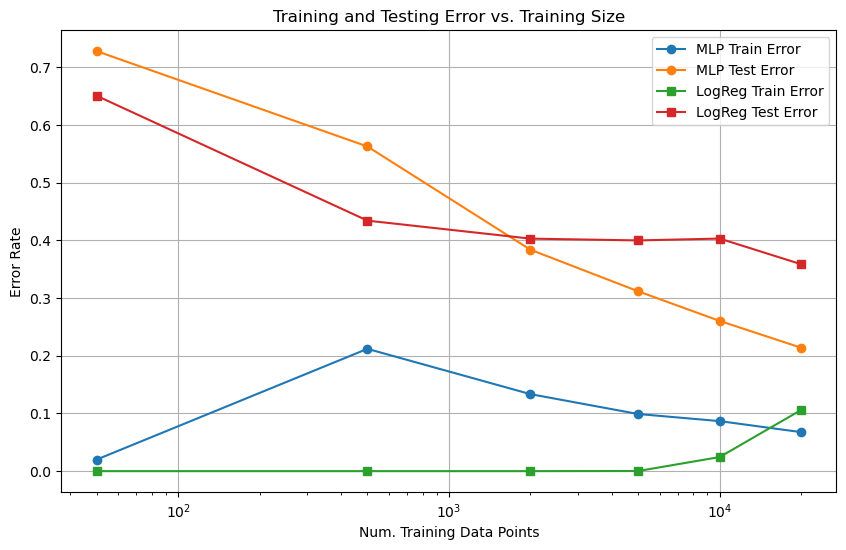

In [10]:
# Do not change this
train_sizes = [50, 500, 2000, 5000, 10000, 20000]
tr_err_mlp, te_err_mlp = errors_for_train_sizes_mlp(X_tr_scaled, y_tr, X_te_scaled, y_te, seed, train_sizes)
tr_err_lr, te_err_lr = errors_for_train_sizes_lr(X_tr_scaled, y_tr, X_te_scaled, y_te, seed, train_sizes)
plot_errors_for_train_sizes_mlp_lr(tr_err_mlp, te_err_mlp, tr_err_lr, te_err_lr, train_sizes)

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---
### Problem 2.3: Learning Curves (10 points)

One hyperparameter that can have a significant effect on the performance of your model is the learning rate, which controls the step size in (stochastic) gradient descent. In this problem you will vary the learning rate to see what effect this has on how quickly training converges as well as the effect on the performance of your model.

In this problem, you should use the following settings for your network:
- A single hidden layer with $64$ hidden nodes
- Use the ReLU activation function
- Train the network using stochastic gradient descent (SGD)
- Set `n_iter_no_change=100` and `max_iter=100`. This ensures that all of your networks in this problem will train for 100 epochs (an *epoch* is one full pass over the training data).
- Use a batch size of 256
- **Make sure to set `random_state=seed`.**

Your task is to:
- Train a neural network with the above settings, but vary the learning rate in `lr = [0.0005, 0.001, 0.005, 0.01]`.
- Create a plot showing the loss on the training set as a function of the training epoch (i.e. the x-axis corresponds to training iterations) for each learning rate above. You should have a single plot with four curves. Make sure to include an x-label, a y-label, and a legend in your plot. (Hint: `MLPClassifier` has an attribute `loss_curve_` that you likely find useful.)
- Include a short description of what you see in your plot.

**Important: To make your code run faster, you should train all of your networks in this problem on only the first 10,000 images of `X_tr`**. In the following cell, you are provided a few lines of code that will create a small training set (with the first 10,000 images in `X_tr`) and a validation set (with the second 10,000 images in `X_tr`). You will use this resampled dataset later in Problem 2.4. 

In [11]:
# Create validation sets from the second 10k images in X_tr_scaled.
X_val_10k = X_tr_scaled[10000:20000]
y_val_10k = y_tr[10000:20000]

# Create a smaller training set with the first 10k images in X_tr_scaled.
X_tr_10k = X_tr_scaled[:10000]
y_tr_10k = y_tr[:10000]

In [12]:
def errors_for_learning_rates_mlp(X_tr: np.array, y_tr: np.array, seed: int, learning_rates: list[float]) -> list[list]:
    err_curves = [] # append loss_curve_ from each MLP model to this list
    ### YOUR CODE STARTS HERE ###
    # MAKE SURE YOU ARE USING THE GIVEN ARGUMENT NAMES
    for lr in learning_rates:
        mlp = MLPClassifier(
            hidden_layer_sizes=(64,),
            activation='relu',
            solver='sgd',
            learning_rate_init=lr,
            batch_size=256,
            max_iter=100,
            n_iter_no_change=100,
            random_state=seed
        )
        mlp.fit(X_tr, y_tr)
        err_curves.append(mlp.loss_curve_)
    ###  YOUR CODE ENDS HERE  ###
    return err_curves 

<!-- BEGIN QUESTION -->



In [13]:
def plot_errors_for_learning_rates_mlp(err_curves: list[list], learning_rates: list[float]) -> None:
    ### YOUR CODE STARTS HERE ###
    plt.figure(figsize=(10, 6))

    for i, curve in enumerate(err_curves):
        plt.plot(range(1, len(curve) + 1), curve, label=f'lr={learning_rates[i]}')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    ###  YOUR CODE ENDS HERE  ###

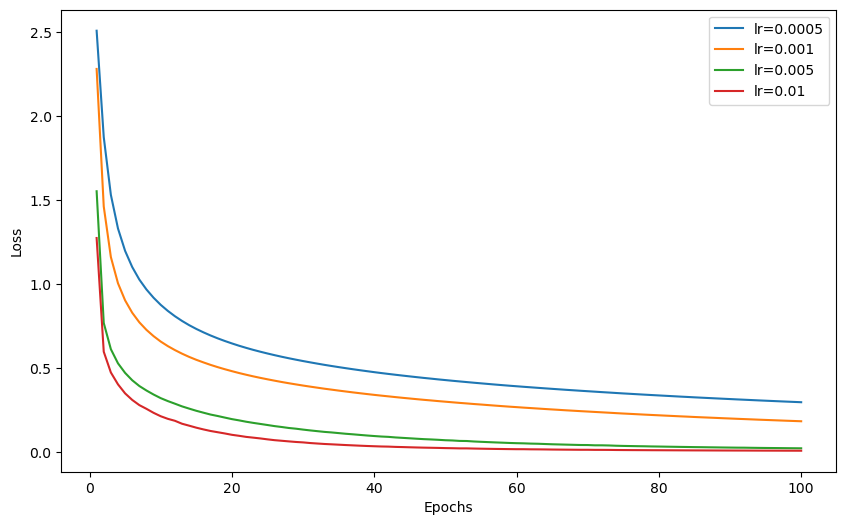

In [14]:
# Do not change this cell.
learning_rates = [0.0005, 0.001, 0.005, 0.01]
err_curves = errors_for_learning_rates_mlp(X_tr_10k, y_tr_10k, seed, learning_rates)
plot_errors_for_learning_rates_mlp(err_curves, learning_rates)

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Problem 2.4: Tuning a Neural Network (30 points)

As you saw in Problem 2.2, there are many hyperparameters of a neural network that can possibly be tuned in order to try to maximize the accuracy of your model. For the final problem of this assignment, it is your job to tune these hyperparameters.

For example, some hyperparameters you might choose to tune are:
- Learning rate
- Depth/width
- Regularization strength
- Activation functions
- Batch size
- etc.

To do this, you should train a network on the training data `X_tr_10k` and evaluate its performance on the validation set `X_val_10k` -- your goal is to achieve the highest possible accuracy on `X_val_10k` by changing the network hyperparameters. **Important: To make your code run faster, you should train all of your networks in this problem on only the first 10,000 images of `X_tr_scaled`**. This was already set up for you in Problem 2.3.

To receive full credit for this problem, you will need to tune your network hyperparameters until you achieve an error rate smaller than 9% on the validation data. However, tuning neural networks can be a difficult task. Hence, you may need to train at least ten+ different neural networks with different settings of the hyperparameters.

In your answer, include a table listing the different hyperparameters that you tried, along with the resulting accuracy on the training and validation sets `X_tr_10k` and `X_val_10k`. Indicate which of these hyperparameter settings you would choose for your final model, and report the accuracy of this final model on the testing set `X_te_scaled`.

In [15]:
# THIS CELL CONTAINS TAGS THAT ARE USED BY THE AUTOGRADER. DO NOT DELETE THIS CELL OR MODIFY THE TAGS

# Problem 2.4: Experiments
# Keep your experiments and results in this cell, or autograder will timeout
# After all the experiments, you should fill in the next cell with the best hyperparameters you have found
### YOUR CODE STARTS HERE ###
results = []

param_grid = [
    {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.005},
    {'hidden_layer_sizes': (128,), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.005},
    {'hidden_layer_sizes': (64, 64), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.005},
    {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'alpha': 1e-4, 'learning_rate_init': 0.005},
    {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 1e-5, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.005},
    {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 1e-4, 'learning_rate_init': 0.01},
]

for params in param_grid:
    mlp = MLPClassifier(
        **params,
        solver='sgd',
        batch_size=256,
        max_iter=100,
        n_iter_no_change=10,
        random_state=seed
    )
    mlp.fit(X_tr_10k, y_tr_10k)
    train_acc = mlp.score(X_tr_10k, y_tr_10k)
    val_acc = mlp.score(X_val_10k, y_val_10k)
    results.append((params, train_acc, val_acc))

# Print results in a readable table
for idx, (params, tr_acc, val_acc) in enumerate(results):
    print(f"[{idx+1}] Train Acc: {tr_acc:.4f}, Val Acc: {val_acc:.4f}, Params: {params}")

### YOUR CODE ENDS HERE ###

[1] Train Acc: 0.9994, Val Acc: 0.8897, Params: {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.005}
[2] Train Acc: 0.9998, Val Acc: 0.9037, Params: {'hidden_layer_sizes': (128,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.005}
[3] Train Acc: 0.9999, Val Acc: 0.8862, Params: {'hidden_layer_sizes': (64, 64), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.005}
[4] Train Acc: 0.9964, Val Acc: 0.8567, Params: {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'alpha': 0.0001, 'learning_rate_init': 0.005}
[5] Train Acc: 0.9805, Val Acc: 0.8885, Params: {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.001}
[6] Train Acc: 0.9807, Val Acc: 0.8883, Params: {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.001}
[7] Train Acc: 1.0000, Val Acc: 0.9028, Params: {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha':

In [16]:
# Fill in your best hyperparameters below, you can freely add or remove keys.
# All the keys corresponds to arguments of MLPClassifier.
# Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
# Make sure the cell can run without errors.

# best_hyperparams = {
#    'hidden_layer_sizes': ...,
#    'activation': ..., 
#    'solver': ...,
#    'alpha': ...,
#    'learning_rate': ...,
#    'learning_rate_init': ...,
#    'max_iter': ...,
#    'n_iter_no_change': ...
#}

### YOUR CODE STARTS HERE ###
best_hyperparams = {
    'hidden_layer_sizes': (128, 64),
    'activation': 'relu',
    'solver': 'sgd',
    'alpha': 1e-4,
    'learning_rate': 'constant',
    'learning_rate_init': 0.005,
    'max_iter': 100,
    'n_iter_no_change': 10
}
###  YOUR CODE ENDS HERE  ###
def train_mlp_with_hyperparameters(best_hyperparams, X_tr_10k, y_tr_10k, X_val_10k, y_val_10k, X_te_scaled, y_te, seed) -> Tuple[float, float, float]:
    mlp = MLPClassifier(**best_hyperparams, shuffle=True, random_state=seed, verbose=False)
    mlp.fit(X_tr_10k, y_tr_10k)
    train_accuracy = mlp.score(X_tr_10k, y_tr_10k)
    val_accuracy = mlp.score(X_val_10k, y_val_10k)
    test_accuracy = mlp.score(X_te_scaled, y_te)
    
    print('Best hyperparameters performance:')
    print(f'Training accuracy: {train_accuracy}')
    print(f'Validation accuracy: {val_accuracy}')
    print(f'Test accuracy: {test_accuracy}')
    return train_accuracy, val_accuracy, test_accuracy

# Check your results
train_mlp_with_hyperparameters(best_hyperparams, X_tr_10k, y_tr_10k, X_val_10k, y_val_10k, X_te_scaled, y_te, seed)

Best hyperparameters performance:
Training accuracy: 1.0
Validation accuracy: 0.9012
Test accuracy: 0.8005


(1.0, 0.9012, 0.8005)

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---
### Statement of Collaboration (5 points)

It is **mandatory** to include a Statement of Collaboration in each submission, with respect to the guidelines below. Include the names of everyone involved in the discussions (especially in-person ones), and what was discussed. If you did not collaborate you can simply write N/A.

All students are required to follow the academic honesty guidelines posted on the course website. For
programming assignments, in particular, I encourage the students to organize (perhaps using Ed) to
discuss the task descriptions, requirements, bugs in my code, and the relevant technical content before they start
working on it. However, you should not discuss the specific solutions, and, as a guiding principle, you are not
allowed to take anything written or drawn away from these discussions (i.e. no photographs of the whiteboard,
written notes, referring to Ed, etc.). Especially after you have started working on the assignment, try
to restrict the discussion to Ed as much as possible, so that there is no doubt as to the extent of your
collaboration.

N/A

<!-- END QUESTION -->

